# The True Cost of Watching: Activator, then the Whole Machine

A two-act cost story for the Activator talk, now built on the aggregate table that actually
answers a query. The per-timepoint detail is sealed behind the app's private connection, but the
day-grain `Metrics By Item Operation And Day` table (the same one Microsoft's FUAM accelerator
harvests) returns real per-operation CU through `evaluate_dax`. So the story runs on live numbers,
no manual export.

**Act 1** looks at the Activator alone. It looks cheap. That is the trap.

**Act 2** adds the eventstream that feeds it, and the story flips: the always-on eventstream
connector, billed per vCore-hour whether or not events flow, is the real cost of keeping the Eye
open. The rule was never the expensive part. The machinery of watching is. And now we can show
the eventstream's own operations, the hourly connector and the processor, standing guard.

**Prerequisites**
- Run in a Fabric notebook, in the Capacity Metrics workspace, with a Lakehouse attached.
- Read plus build permission on the Fabric Capacity Metrics semantic model.
- Data lags 10 to 15 minutes and always-on costs bill continuously, so give the demo an hour or
  two before the numbers settle.


In [1]:
import pandas as pd
import sempy.fabric as fabric
from datetime import datetime, timedelta, timezone

# ----------------------------------------------------------------------
# CONFIG  (prefilled from the demo build; confirm they match your tenant)
# ----------------------------------------------------------------------
WORKSPACE_ID = "838abd20-22f3-424b-b8ba-f6df4a0c4006"   # Capacity Metrics workspace
DATASET_ID   = "c0563d4a-98a0-4247-bd20-466b36b28bbd"   # Capacity Metrics semantic model
CAPACITY_ID  = "77d58d8e-8ffd-40f3-a313-c7f98959ddd2"   # your capacity

# Your demo items, named exactly as they appear in the Metrics app Items table
EVENTSTREAM_ITEM = "es_saurons_influence"
ACTIVATOR_ITEMS  = ["ac_the_eye", "ac_eye_of_sauron"]
ACTIVATOR_KINDS  = ["Activator", "Reflex"]   # Reflex is the older label for Activator

DAYS_IN_SCOPE = 7           # how many recent days to accumulate for the story
HISTORY_TABLE = "activator_watch_cost_history"
WRITE_HISTORY = True       # flip to True when you want to persist a snapshot

# ---- Pricing: US list rates, illustrative, ~mid 2026. Confirm in the Azure calculator. ----
# Rates are per CU-hour and scale linearly across F SKUs, so this works for any SKU.
PAYG_PER_CU_HOUR     = 0.18      # pay-as-you-go, US region
RESERVED_PER_CU_HOUR = 0.1071    # 1-year reserved (~41% less; matches F64 ~$5,003/month)


StatementMeta(, ce264de5-da96-440d-8f00-5aaabee5133a, 3, Finished, Available, Finished, False)

In [2]:
# ----------------------------------------------------------------------
# Engine: pull per-operation CU from the day-grain aggregate for the window.
# This replaces the old dynamic-measure calibration, which returned blank
# because those measures need the app's timepoint context. The aggregate
# table does not, so it answers cleanly.
# ----------------------------------------------------------------------

def run_dax(dax):
    return fabric.evaluate_dax(DATASET_ID, dax, workspace=WORKSPACE_ID)

def get_window():
    """Rolling window anchored on the newest date the model holds (avoids clock offset)."""
    try:
        probe = f"""
        DEFINE MPARAMETER 'CapacitiesList' = {{ "{CAPACITY_ID}" }}
        EVALUATE ROW("MaxDate", MAX('Metrics By Item Operation And Day'[Date]))
        """
        anchor = pd.to_datetime(run_dax(probe).iloc[0, 0]).date()
    except Exception as e:
        anchor = datetime.now(timezone.utc).date()
        print(f"max-date probe failed, using {anchor}. ({str(e)[:90]})")
    return [anchor - timedelta(days=i) for i in range(DAYS_IN_SCOPE - 1, -1, -1)]

def pull_window():
    frames = []
    for d in get_window():
        dax = f"""
        DEFINE
            MPARAMETER 'CapacitiesList' = {{ "{CAPACITY_ID}" }}
            VAR core =
                SUMMARIZECOLUMNS(
                    'Items'[Item name],
                    'Items'[Item kind],
                    'Metrics By Item Operation And Day'[Operation name],
                    'Metrics By Item Operation And Day'[Date],
                    FILTER(Capacities, Capacities[Capacity Id] = "{CAPACITY_ID}"),
                    FILTER(
                        KEEPFILTERS(VALUES('Metrics By Item Operation And Day'[Date])),
                        'Metrics By Item Operation And Day'[Date] = DATE({d.year}, {d.month}, {d.day})
                    ),
                    "CU_s",  SUM('Metrics By Item Operation And Day'[CU (s)]),
                    "Dur_s", SUM('Metrics By Item Operation And Day'[Duration (s)]),
                    "Ops",   SUM('Metrics By Item Operation And Day'[Operations])
                )
        EVALUATE FILTER(core, [CU_s] > 0)
        """
        try:
            r = run_dax(dax)
            if len(r) > 0:
                frames.append(r)
        except Exception as e:
            print(f"  {d}: {str(e)[:120]}")
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    df.columns = [c.split("[")[-1].rstrip("]").strip().lower().replace(" ", "_") for c in df.columns]
    for n in ["cu_s", "dur_s", "ops"]:
        if n in df.columns:
            df[n] = pd.to_numeric(df[n], errors="coerce").fillna(0.0)
    return df

raw = pull_window()
n_days = raw["date"].nunique() if not raw.empty else 0
print(f"pulled {len(raw)} item/operation rows across {n_days} day(s)")

# Slice to the demo items for the story
DEMO_ITEMS = [EVENTSTREAM_ITEM] + ACTIVATOR_ITEMS
watch = raw[raw["item_name"].isin(DEMO_ITEMS)].copy() if not raw.empty else raw
if watch.empty:
    print("No rows for the demo items yet. Widen DAYS_IN_SCOPE, or confirm the item names.")
else:
    print("demo item/operation rows:", len(watch))


StatementMeta(, ce264de5-da96-440d-8f00-5aaabee5133a, 4, Finished, Available, Finished, False)

pulled 1080 item/operation rows across 7 day(s)
demo item/operation rows: 19


## Act 1: The rule looks harmless

We ask only about the Activator items. This is the number a skeptic would quote to say
"Activator is cheap." Watch how small it is.


In [3]:
if not watch.empty:
    act1 = watch[watch["item_kind"].isin(ACTIVATOR_KINDS) |
                 watch["item_name"].isin(ACTIVATOR_ITEMS)]
    by_item = (act1.groupby(["item_name", "item_kind"], as_index=False)["cu_s"]
                   .sum().sort_values("cu_s", ascending=False))
    print("Act 1 - Activator items only:\n")
    print(by_item.to_string(index=False) if not by_item.empty else "  (no Activator CU recorded)")
    print(f"\nActivator total: {act1['cu_s'].sum():,.1f} CU seconds")
    print("Looks cheap, right? Hold that thought.")
else:
    print("Run the engine cell first.")


StatementMeta(, ce264de5-da96-440d-8f00-5aaabee5133a, 5, Finished, Available, Finished, False)

Act 1 - Activator items only:

 item_name item_kind    cu_s
ac_the_eye Activator  146.52

Activator total: 146.5 CU seconds
Looks cheap, right? Hold that thought.


## Wait a minute. The rule was never the whole story.

An Activator cannot watch anything on its own. To keep one eye on Middle-earth you have to keep
an **eventstream** running around the clock, feeding it. That connector is billed per vCore-hour
whether or not a single event flows, exactly like the Activator's listener, but far larger.

So the honest cost of the Eye is not the rule. It is the rule **plus** the eventstream standing
guard behind it. Let us add the eventstream and rerun.


In [4]:
if not watch.empty:
    by_item = (watch.groupby(["item_name", "item_kind"], as_index=False)["cu_s"]
                    .sum().sort_values("cu_s", ascending=False))
    print("Act 2 - The true cost of watching (Activator + Eventstream):\n")
    print(by_item.to_string(index=False))

    total = by_item["cu_s"].sum()
    es_cu = by_item.loc[by_item["item_name"] == EVENTSTREAM_ITEM, "cu_s"].sum()
    print(f"\nTotal cost of watching: {total:,.1f} CU seconds")
    if total:
        print(f"The eventstream alone is {es_cu:,.1f} CU seconds, {100 * es_cu / total:.0f}% of the bill.")

    # The new part: the eventstream's own operations, the machinery standing guard.
    es_ops = (watch[watch["item_name"] == EVENTSTREAM_ITEM]
                  .groupby("operation_name", as_index=False)["cu_s"]
                  .sum().sort_values("cu_s", ascending=False))
    if not es_ops.empty:
        print("\nWhat the eventstream is actually spending on (its operations):")
        print(es_ops.to_string(index=False))
    print("\nThe rule was never the cost. The machinery of watching is.")
else:
    print("Run the engine cell first.")


StatementMeta(, ce264de5-da96-440d-8f00-5aaabee5133a, 6, Finished, Available, Finished, False)

Act 2 - The true cost of watching (Activator + Eventstream):

           item_name   item_kind          cu_s
es_saurons_influence EventStream  25524.167005
          ac_the_eye   Activator        146.52

Total cost of watching: 25,670.7 CU seconds
The eventstream alone is 25,524.2 CU seconds, 99% of the bill.

What the eventstream is actually spending on (its operations):
                       operation_name        cu_s
       Eventstream Processor Per Hour     19130.6
                 Eventstream Per Hour  6337.92906
              OneLake Write via Proxy     27.8046
           OneLake Write via Redirect     18.5364
      Eventstream Data Traffic Per GB    3.296145
OneLake Other Operations Via Redirect      2.5272
               OneLake Read via Proxy      1.9968
             OneLake Other Operations         1.3
            OneLake Read via Redirect      0.1768

The rule was never the cost. The machinery of watching is.


StatementMeta(, ce264de5-da96-440d-8f00-5aaabee5133a, 7, Finished, Available, Finished, False)

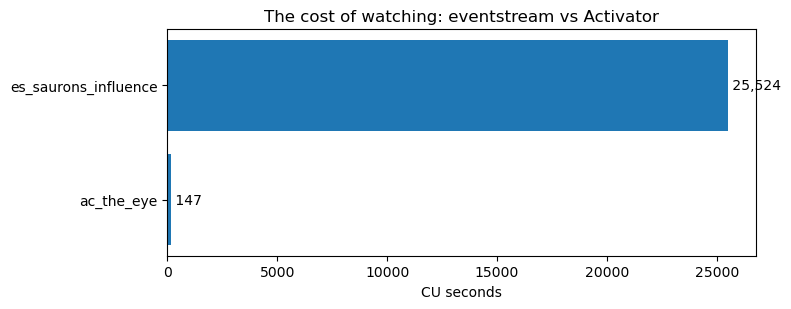

In [5]:
# Optional: a bar chart for the reveal slide. Eventstream towers over the Activator.
try:
    import matplotlib.pyplot as plt
    if not watch.empty:
        bi = (watch.groupby("item_name", as_index=False)["cu_s"].sum()
                   .sort_values("cu_s"))
        fig, ax = plt.subplots(figsize=(8, 3.2))
        ax.barh(bi["item_name"], bi["cu_s"])
        ax.set_xlabel("CU seconds")
        ax.set_title("The cost of watching: eventstream vs Activator")
        for i, v in enumerate(bi["cu_s"]):
            ax.text(v, i, f" {v:,.0f}", va="center")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("chart skipped:", str(e)[:100])


In [6]:
# ----------------------------------------------------------------------
# Project the always-on cost of keeping the Eye open, from the observed
# daily rate. Both the eventstream connector and the Activator listener
# bill continuously, so the daily total scales cleanly with time.
# ----------------------------------------------------------------------
PRICE_PER_CU_HOUR = None   # optional, e.g. 0.18 for a rough F64 PAYG rate; None skips cost

if not watch.empty and n_days > 0:
    total_cu   = watch["cu_s"].sum()
    per_day_cu = total_cu / n_days
    horizons   = {"Day": 1, "Week": 7, "Month": 30, "Quarter": 91, "Year": 365}

    rows = []
    for label, mult in horizons.items():
        cu_s = per_day_cu * mult
        row = {"horizon": label, "cu_seconds": round(cu_s, 1), "cu_hours": round(cu_s / 3600.0, 2)}
        if PRICE_PER_CU_HOUR is not None:
            row["est_cost"] = round(cu_s / 3600.0 * PRICE_PER_CU_HOUR, 2)
        rows.append(row)

    print(f"Observed {per_day_cu:,.1f} CU seconds/day across {n_days} day(s). Projected:\n")
    print(pd.DataFrame(rows).to_string(index=False))
    print("\nMost of that is the eventstream standing guard, not the rule that fires.")
else:
    print("Run Act 2 first.")


StatementMeta(, ce264de5-da96-440d-8f00-5aaabee5133a, 8, Finished, Available, Finished, False)

Observed 3,667.2 CU seconds/day across 7 day(s). Projected:

horizon  cu_seconds  cu_hours
    Day      3667.2      1.02
   Week     25670.7      7.13
  Month    110017.2     30.56
Quarter    333718.9     92.70
   Year   1338543.0    371.82

Most of that is the eventstream standing guard, not the rule that fires.


## Putting a dollar figure on it

CU seconds are the meter, but nobody budgets in CU seconds. The conversion is simple: divide CU
seconds by 3,600 to get CU hours, then multiply by the price per CU hour. Fabric prices capacity
per CU hour, and that rate scales linearly across the F SKUs, so this works no matter which SKU
you run.

Two rates matter, both set in the config cell and both easy to change for your region:

- **Pay-as-you-go**, about **$0.18 per CU hour** in US regions. Flexible, and you can pause the
  capacity to stop the meter.
- **1-year reserved**, about **$0.107 per CU hour**, roughly **41% cheaper**, but it runs
  continuously and cannot be paused.

These are illustrative US list rates from mid 2026. Regions vary by 10 to 15%, so confirm yours in
the Azure pricing calculator before you quote a number to finance.


In [7]:
# ----------------------------------------------------------------------
# CU seconds -> dollars, at both rates, projected across a year.
#   CU hours = CU seconds / 3600
#   dollars  = CU hours * rate per CU hour
# Per-day rate uses each item's OWN active days, not the window's total days,
# so an item that ran on 2 of 7 days is not smeared across all 7.
# ----------------------------------------------------------------------
if not watch.empty:
    # active days per item: how many distinct dates that item actually appears on
    active = (watch.groupby("item_name")["date"].nunique()
                   .rename("active_days").reset_index())

    p = watch.groupby(["item_name", "item_kind"], as_index=False)["cu_s"].sum()
    p = p.merge(active, on="item_name", how="left")

    p["cu_s_per_active_day"] = p["cu_s"] / p["active_days"]
    p["cu_hours_per_year"]   = p["cu_s_per_active_day"] * 365 / 3600.0
    p["usd_year_payg"]       = (p["cu_hours_per_year"] * PAYG_PER_CU_HOUR).round(2)
    p["usd_year_reserved"]   = (p["cu_hours_per_year"] * RESERVED_PER_CU_HOUR).round(2)

    show = (p[["item_name", "item_kind", "active_days",
               "cu_s_per_active_day", "usd_year_payg", "usd_year_reserved"]]
              .sort_values("usd_year_payg", ascending=False))
    print(f"Projected annual cost of watching "
          f"(PAYG ${PAYG_PER_CU_HOUR:.3f}/CU-hr, Reserved ${RESERVED_PER_CU_HOUR:.4f}/CU-hr):\n")
    print(show.to_string(index=False))

    tot_payg = p["usd_year_payg"].sum()
    tot_res  = p["usd_year_reserved"].sum()
    es_payg  = p.loc[p["item_name"] == EVENTSTREAM_ITEM, "usd_year_payg"].sum()

    print(f"\nKeeping the Eye open for a full year:")
    print(f"  Pay-as-you-go : ${tot_payg:,.2f}")
    print(f"  Reserved 1-yr : ${tot_res:,.2f}   (about {100*(1-tot_res/tot_payg):.0f}% less)")
    if tot_payg:
        print(f"  The eventstream is ${es_payg:,.2f} of the PAYG total, {100*es_payg/tot_payg:.0f}% of it.")

    paused = tot_payg * 40.0 / 168.0
    print(f"\n  If you pause the capacity nights and weekends (PAYG only), the meter stops when")
    print(f"  it is off, and the annual figure falls to roughly ${paused:,.2f}.")
    print(f"  Reserved cannot be paused, so its ${tot_res:,.2f} stands whether the Eye watches or not.")
else:
    print("Run Act 2 first.")

StatementMeta(, ce264de5-da96-440d-8f00-5aaabee5133a, 9, Finished, Available, Finished, False)

Projected annual cost of watching (PAYG $0.180/CU-hr, Reserved $0.1071/CU-hr):

           item_name   item_kind  active_days  cu_s_per_active_day  usd_year_payg  usd_year_reserved
es_saurons_influence EventStream            2         12762.083503         232.91             138.58
          ac_the_eye   Activator            1               146.52           2.67               1.59

Keeping the Eye open for a full year:
  Pay-as-you-go : $235.58
  Reserved 1-yr : $140.17   (about 41% less)
  The eventstream is $232.91 of the PAYG total, 99% of it.

  If you pause the capacity nights and weekends (PAYG only), the meter stops when
  it is off, and the annual figure falls to roughly $56.09.
  Reserved cannot be paused, so its $140.17 stands whether the Eye watches or not.


## What the dollar figure is telling you

The number that matters is not the total, it is the shape of it. Almost all of the annual dollars
belong to the eventstream, and almost none to the Activator rule everyone assumed was the cost.
The rule is loose change. The always-on connector behind it is the bill. That is the whole lesson
in one line of a budget.

The pay-as-you-go and reserved figures frame the choice honestly. Reserved is roughly 41% cheaper,
which is the right call for anything that genuinely runs all year, and an always-on eventstream is
exactly that. But reserved removes your only real lever, the pause. On pay-as-you-go you can turn
the capacity off nights and weekends and the meter stops, which is why the paused figure above is a
fraction of the round-the-clock one. So the cheapest path is not simply reserved, it is deciding
whether the Eye truly needs to watch every hour, or only during the hours anyone is home to answer
the alarm.

Scale is the last point to make on stage. This is a trivial demo stream, so the dollars are modest.
In a real deployment the eventstream carries production traffic and the same math produces a number
with more zeros, while the Activator rule stays loose change. The ratio holds, and the ratio is the
lesson: you are billed for the standing watch, not the moment of action. A rule nobody deleted, on
a stream nobody paused, is a line item that never sleeps.

*Rates are illustrative US list values and vary by region and agreement. Confirm in the Azure
pricing calculator before quoting a figure.*


In [8]:
# ----------------------------------------------------------------------
# Append a snapshot, replacing any existing rows for the same capacity
# and dates. Safe to rerun: one row set per day, no duplicates.
# ----------------------------------------------------------------------
if WRITE_HISTORY and not watch.empty:
    from pyspark.sql import functions as F

    snap = watch.copy()
    # normalize the date to a plain YYYY-MM-DD string for clean matching
    snap["metric_date"] = pd.to_datetime(snap["date"]).dt.strftime("%Y-%m-%d")
    snap = snap.drop(columns=["date"])
    snap.columns = [c.replace(" ", "_") for c in snap.columns]

    sdf = (spark.createDataFrame(snap)
              .withColumn("captured_at", F.current_timestamp())
              .withColumn("capacity_id", F.lit(CAPACITY_ID)))

    dates_in_scope = sorted(snap["metric_date"].unique().tolist())
    dmin, dmax = dates_in_scope[0], dates_in_scope[-1]

    try:
        exists = spark.catalog.tableExists(HISTORY_TABLE)
    except Exception:
        exists = False

    if exists:
        from delta.tables import DeltaTable
        cond = (f"capacity_id = '{CAPACITY_ID}' "
                f"AND metric_date >= '{dmin}' AND metric_date <= '{dmax}'")
        DeltaTable.forName(spark, HISTORY_TABLE).delete(cond)
        sdf.write.mode("append").format("delta").option("mergeSchema", "true").saveAsTable(HISTORY_TABLE)
    else:
        sdf.write.mode("overwrite").format("delta").option("mergeSchema", "true").saveAsTable(HISTORY_TABLE)

    print(f"Replaced and wrote {sdf.count()} rows for {dmin}..{dmax} in '{HISTORY_TABLE}'.")
else:
    print("WRITE_HISTORY is False (or nothing to write). No snapshot saved.")


StatementMeta(, ce264de5-da96-440d-8f00-5aaabee5133a, 10, Finished, Available, Finished, False)

Replaced and wrote 19 rows for 2026-07-09..2026-07-10 in 'activator_watch_cost_history'.


## Reading it for the stage

The story now has a real turn, runs on live numbers, and ends in dollars:

- **Act 1** shows the Activator alone, almost nothing.
- **Act 2** adds the eventstream and the number jumps, with the operation breakdown showing the
  hourly connector and processor billing while nothing happens.
- **The dollars** turn that into an annual figure at both rates, and show how much the pause lever
  saves on pay-as-you-go.

The One Ring was never just the rule. It is the whole apparatus of watchfulness: an eventstream
running around the clock so a rule can wait for something that may never come. That is the Eye that
never sleeps, and it bills by the hour.

### Honest notes for questions

- The source that publishes events is charged too in a real deployment, so the full pattern is
  source plus eventstream plus Activator. Here `nb_the_ring` stands in for the source, so its CU is
  demo-only and not counted.
- The projection treats the daily rate as steady, which is fair for the always-on connector and
  listener. Event bursts add variable cost on top.
- Prices are illustrative US list rates and scale linearly per CU hour. Confirm your region in the
  Azure calculator before quoting finance.
- Numbers come from the day-grain aggregate, which is what the app rolls up to. If a table or
  column name errors after a Metrics app update, rerun the schema probe (section 11 of the runbook)
  and adjust. Notebook 07 automates this same pull on a schedule.
